# House Prices Model Training

This notebook demonstrates the complete pipeline for training a baseline regression model on the House Prices dataset.

## Steps:
1. Load the data
2. Clean the data
3. Engineer features
4. Train multiple models
5. Evaluate and compare models
6. Make predictions on test set

In [1]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.load_data import load_train_data, load_test_data
from src.clean_data import clean_data
from src.feature_engineering import engineer_features, select_features
from src.train_model import (
    split_data,
    train_linear_regression,
    train_ridge_regression,
    train_random_forest,
    evaluate_model,
    cross_validate_model,
    save_model
)

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load the Data

In [2]:
# Load training and test data
try:
    train_df = load_train_data()
    test_df = load_test_data()
    print(f"Training data shape: {train_df.shape}")
    print(f"Test data shape: {test_df.shape}")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please download the dataset and place it in data/raw/")

Loaded training data: 1460 rows, 81 columns
Loaded test data: 1459 rows, 80 columns
Training data shape: (1460, 81)
Test data shape: (1459, 80)


## 2. Clean the Data

In [3]:
# Clean training data
train_cleaned = clean_data(train_df, is_training=True)
print(f"\nCleaned training data shape: {train_cleaned.shape}")

Cleaning data: 1460 rows, 81 columns
After handling missing values: 1460 rows, 81 columns
Removed 22 outliers based on SalePrice
After removing outliers: 1438 rows, 81 columns

Cleaned training data shape: (1438, 81)


In [4]:
# Clean test data (no outlier removal)
test_cleaned = clean_data(test_df, is_training=False)
print(f"Cleaned test data shape: {test_cleaned.shape}")

Cleaning data: 1459 rows, 80 columns
After handling missing values: 1459 rows, 80 columns
Cleaned test data shape: (1459, 80)


## 3. Engineer Features

In [5]:
# Engineer features for training data
train_featured = engineer_features(train_cleaned, encode=True)
X_train, y_train = select_features(train_featured, 'SalePrice')

print(f"\nFeature matrix shape: {X_train.shape}")
print(f"Target vector shape: {y_train.shape}")

Engineering features: 1438 rows, 81 columns
After feature engineering: 1438 rows, 91 columns

Feature matrix shape: (1438, 89)
Target vector shape: (1438,)


In [6]:
# Engineer features for test data
test_featured = engineer_features(test_cleaned, encode=True)
X_test, _ = select_features(test_featured, 'SalePrice')

print(f"Test feature matrix shape: {X_test.shape}")

Engineering features: 1459 rows, 80 columns
After feature engineering: 1459 rows, 90 columns
Test feature matrix shape: (1459, 89)


In [7]:
# Ensure train and test have the same features
# Get common columns
common_cols = X_train.columns.intersection(X_test.columns)
print(f"\nNumber of common features: {len(common_cols)}")

X_train = X_train[common_cols]
X_test = X_test[common_cols]


Number of common features: 89


## 4. Split Data for Validation

In [8]:
# Split into train and validation sets
X_tr, X_val, y_tr, y_val = split_data(X_train, y_train, test_size=0.2, random_state=42)

Training set: 1150 samples
Validation set: 288 samples


## 5. Train Multiple Models

In [9]:
# Train Linear Regression
print("="*60)
print("Training Linear Regression...")
print("="*60)
lr_model = train_linear_regression(X_tr, y_tr)
lr_metrics = evaluate_model(lr_model, X_val, y_val)

Training Linear Regression...
Linear Regression model trained

Model Evaluation Metrics:
RMSE: $25,349.75
MAE: $17,326.79
R² Score: 0.8517
RMSLE: 0.1639


In [10]:
# Train Ridge Regression
print("\n" + "="*60)
print("Training Ridge Regression...")
print("="*60)
ridge_model = train_ridge_regression(X_tr, y_tr, alpha=10.0)
ridge_metrics = evaluate_model(ridge_model, X_val, y_val)


Training Ridge Regression...
Ridge Regression model trained (alpha=10.0)

Model Evaluation Metrics:
RMSE: $25,335.11
MAE: $17,209.71
R² Score: 0.8518
RMSLE: 0.1684


In [11]:
# Train Random Forest
print("\n" + "="*60)
print("Training Random Forest...")
print("="*60)
rf_model = train_random_forest(X_tr, y_tr, n_estimators=100, random_state=42)
rf_metrics = evaluate_model(rf_model, X_val, y_val)


Training Random Forest...
Random Forest model trained (100 trees)

Model Evaluation Metrics:
RMSE: $26,903.19
MAE: $16,872.24
R² Score: 0.8329
RMSLE: 0.1410


## 6. Compare Models

In [12]:
# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Random Forest'],
    'RMSE': [lr_metrics['RMSE'], ridge_metrics['RMSE'], rf_metrics['RMSE']],
    'MAE': [lr_metrics['MAE'], ridge_metrics['MAE'], rf_metrics['MAE']],
    'R2': [lr_metrics['R2'], ridge_metrics['R2'], rf_metrics['R2']],
    'RMSLE': [lr_metrics['RMSLE'], ridge_metrics['RMSLE'], rf_metrics['RMSLE']]
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))

# Identify best model based on RMSLE (common metric for this competition)
best_idx = comparison['RMSLE'].idxmin()
print(f"\nBest model based on RMSLE: {comparison.loc[best_idx, 'Model']}")


Model Comparison:
            Model         RMSE          MAE       R2    RMSLE
Linear Regression 25349.745565 17326.789949 0.851669 0.163902
 Ridge Regression 25335.112991 17209.713628 0.851840 0.168418
    Random Forest 26903.189509 16872.242743 0.832933 0.140970

Best model based on RMSLE: Random Forest


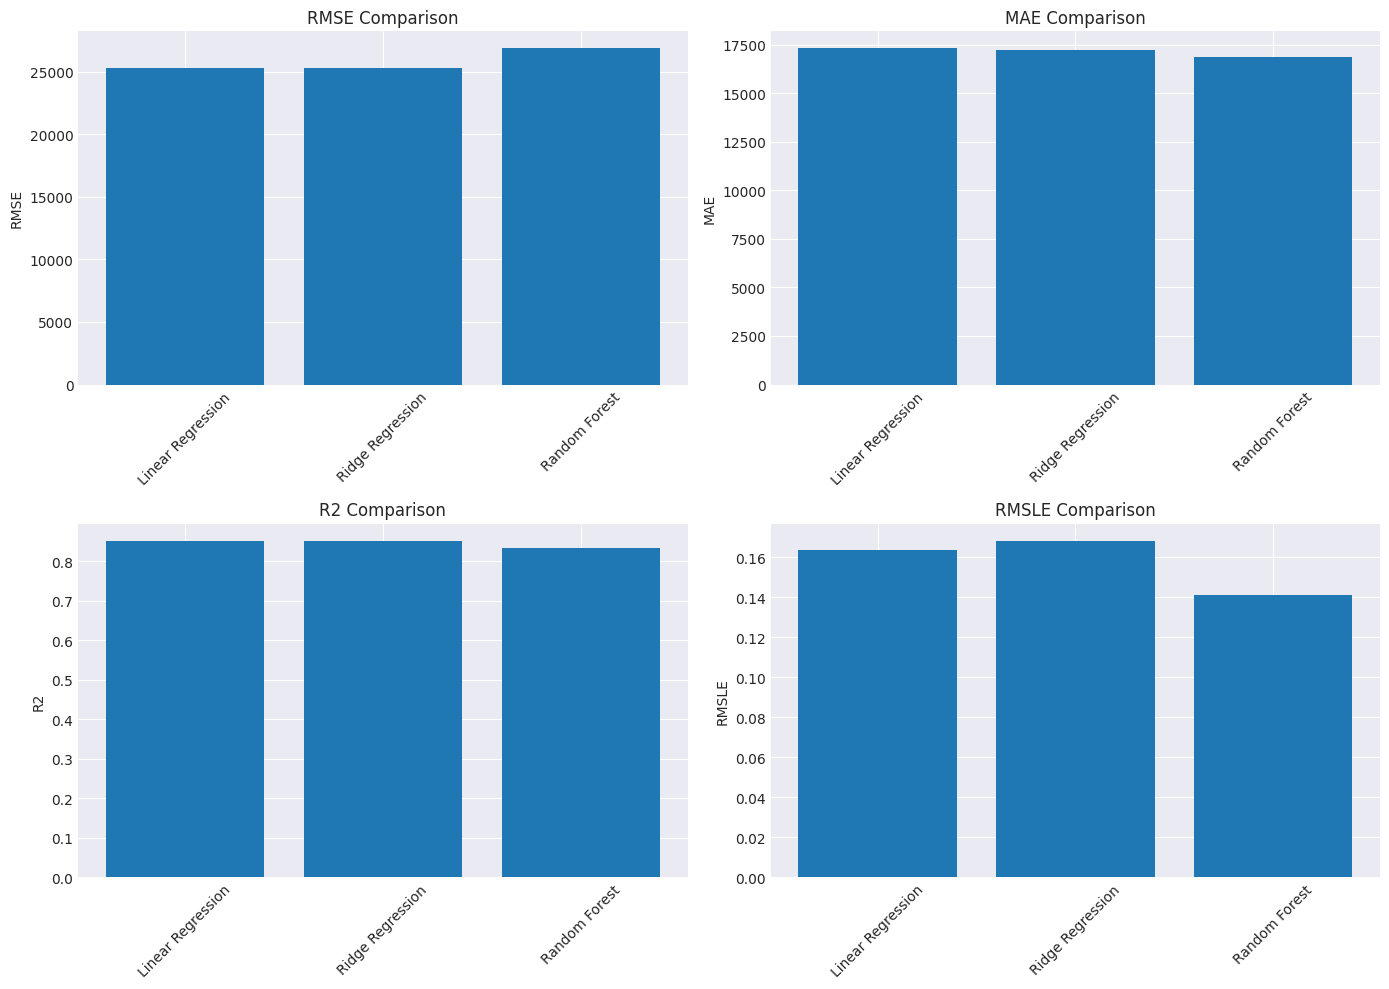

In [13]:
# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['RMSE', 'MAE', 'R2', 'RMSLE']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(comparison['Model'], comparison[metric])
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. Cross-Validation

In [14]:
# Perform cross-validation on the best model (Random Forest)
print("Performing 5-fold cross-validation on Random Forest...")
cv_results = cross_validate_model(rf_model, X_train, y_train, cv=5)

Performing 5-fold cross-validation on Random Forest...

5-Fold Cross-Validation Results:
Mean RMSE: $23,149.87
Std RMSE: $2,545.95


## 8. Make Predictions on Test Set

In [15]:
# Retrain best model on full training data
print("\nRetraining Random Forest on full training data...")
final_model = train_random_forest(X_train, y_train, n_estimators=100, random_state=42)


Retraining Random Forest on full training data...
Random Forest model trained (100 trees)


In [16]:
# Make predictions on test set
test_predictions = final_model.predict(X_test)

print(f"\nGenerated {len(test_predictions)} predictions for the test set")
print(f"Prediction range: ${test_predictions.min():,.2f} - ${test_predictions.max():,.2f}")


Generated 1459 predictions for the test set
Prediction range: $60,415.88 - $372,697.52


In [17]:
# Create submission file
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

# Save to CSV
submission_path = '../data/processed/submission.csv'
submission.to_csv(submission_path, index=False)
print(f"\nSubmission file saved to {submission_path}")
print("\nFirst few predictions:")
print(submission.head())


Submission file saved to ../data/processed/submission.csv

First few predictions:
     Id  SalePrice
0  1461  125219.00
1  1462  153839.00
2  1463  176906.52
3  1464  182636.82
4  1465  193946.47


## 9. Save the Model

In [18]:
# Save the trained model
save_model(final_model)


Model saved to /workspaces/ai365-pandas_houseprice_pipeline/notebooks/../data/processed/model.pkl


## Summary

This notebook demonstrated the complete pipeline:
1. **Data Loading**: Loaded training and test datasets
2. **Data Cleaning**: Handled missing values and removed outliers
3. **Feature Engineering**: Created new features and encoded categorical variables
4. **Model Training**: Trained multiple regression models
5. **Model Evaluation**: Compared models using RMSE, MAE, R², and RMSLE
6. **Cross-Validation**: Validated model performance
7. **Predictions**: Generated predictions for the test set

## Next Steps
- Experiment with more advanced feature engineering
- Try hyperparameter tuning (GridSearchCV, RandomizedSearchCV)
- Ensemble different models
- Apply feature selection techniques
- Try other algorithms (XGBoost, LightGBM, etc.)